Using device: cuda
Training samples: 20000
Test samples: 5000


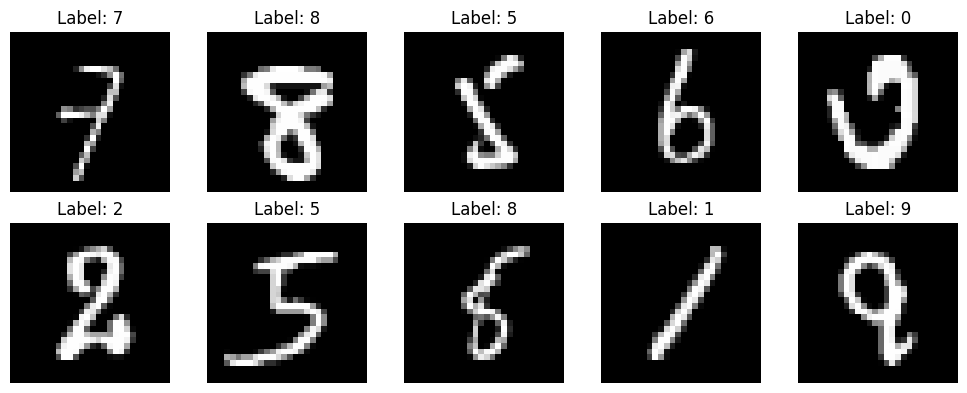

Training standard autoencoder...

[AE] Epoch 1/10 | Train Loss: 215.2699 | Test Loss: 177.0024
[AE] Epoch 2/10 | Train Loss: 178.5363 | Test Loss: 171.4347
[AE] Epoch 3/10 | Train Loss: 173.4761 | Test Loss: 167.0338
[AE] Epoch 4/10 | Train Loss: 168.5357 | Test Loss: 163.8487
[AE] Epoch 5/10 | Train Loss: 165.2336 | Test Loss: 161.2119
[AE] Epoch 6/10 | Train Loss: 162.8276 | Test Loss: 159.6693
[AE] Epoch 7/10 | Train Loss: 160.9858 | Test Loss: 158.1914
[AE] Epoch 8/10 | Train Loss: 159.6197 | Test Loss: 157.5641
[AE] Epoch 9/10 | Train Loss: 158.3810 | Test Loss: 156.0849
[AE] Epoch 10/10 | Train Loss: 157.4095 | Test Loss: 155.9503

Training variational autoencoder...

[VAE] Epoch 1/10 | Train Total: 227.0498 | Train Recon: 219.8557 | Train KL: 7.1942 | Test Total: 186.2549 | Test Recon: 180.4130 | Test KL: 5.8419
[VAE] Epoch 2/10 | Train Total: 184.7294 | Train Recon: 178.6507 | Train KL: 6.0788 | Test Total: 177.1871 | Test Recon: 171.8782 | Test KL: 5.3088
[VAE] Epoch 3/10 | Tr

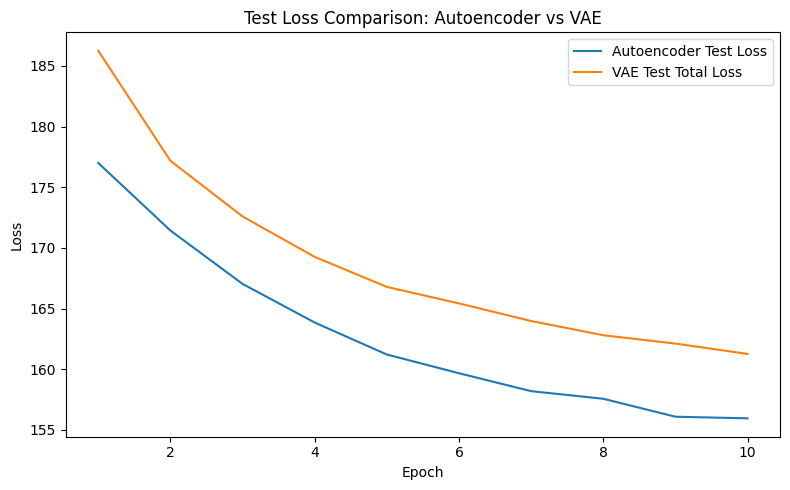

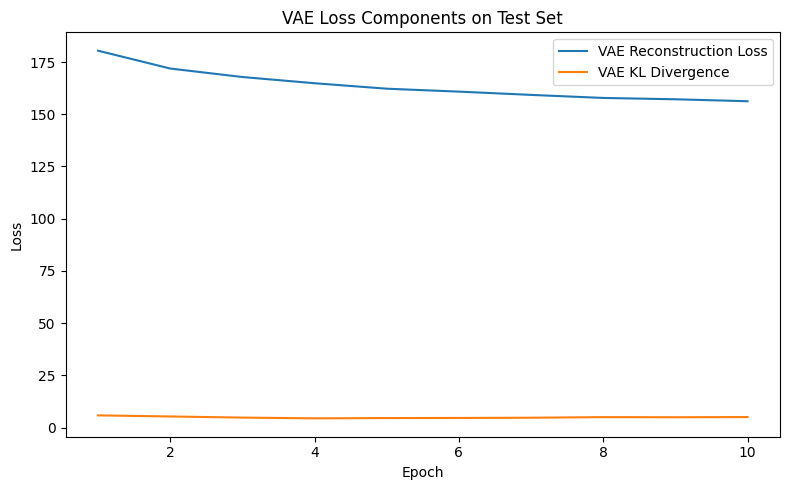

Standard Autoencoder Reconstructions


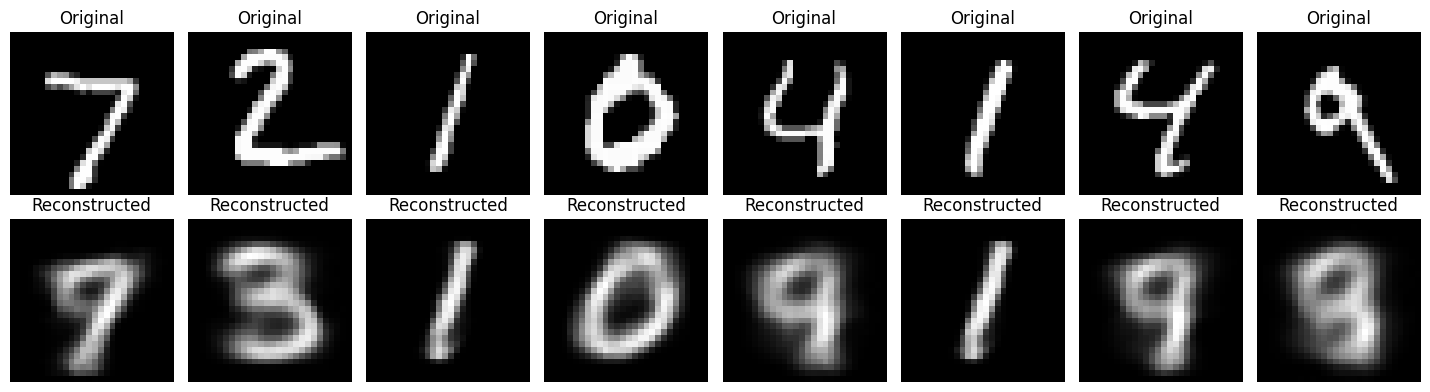

Variational Autoencoder Reconstructions


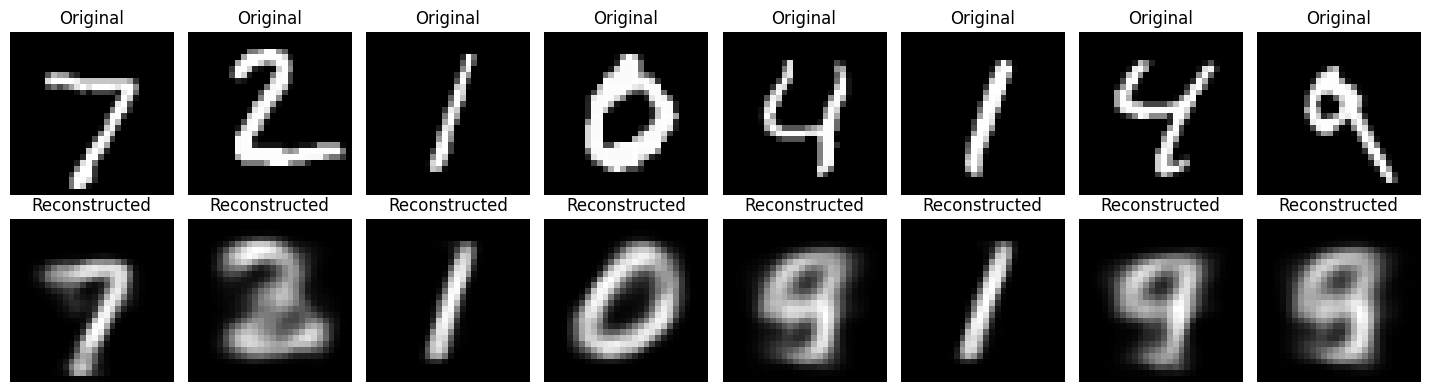

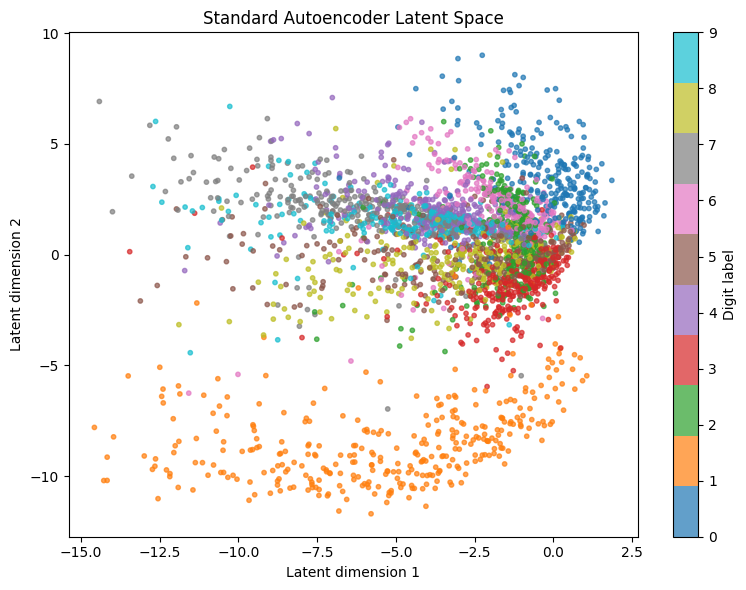

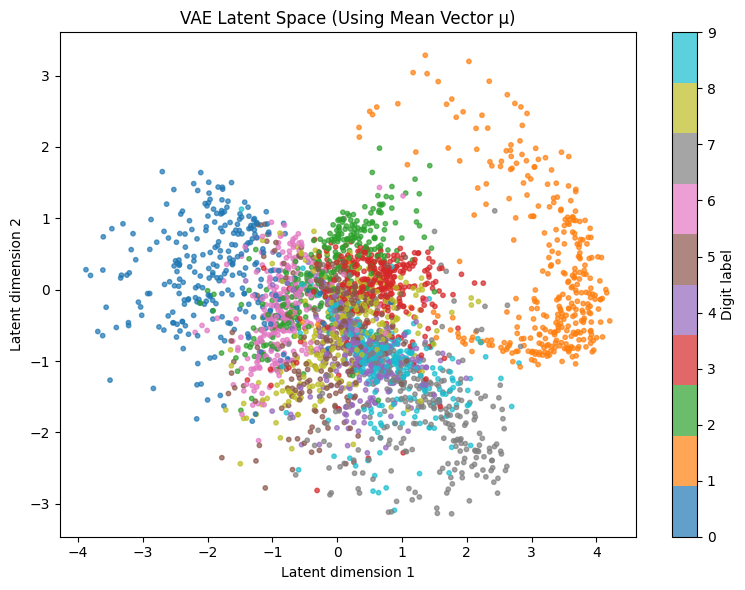

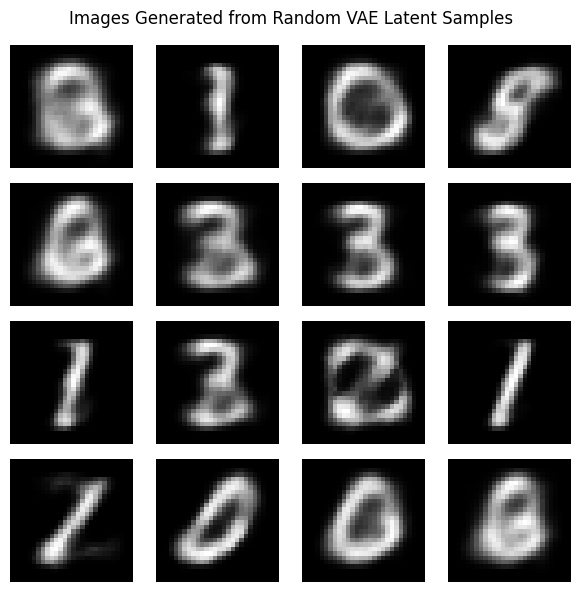

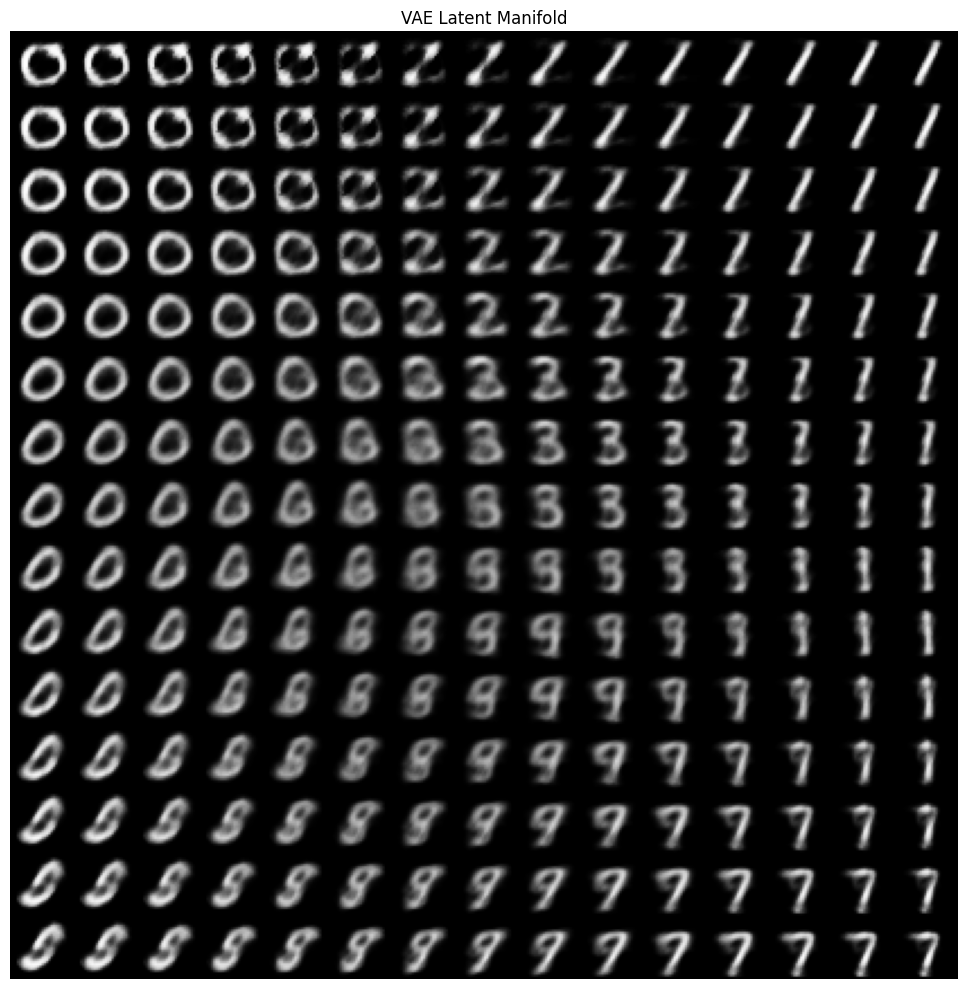

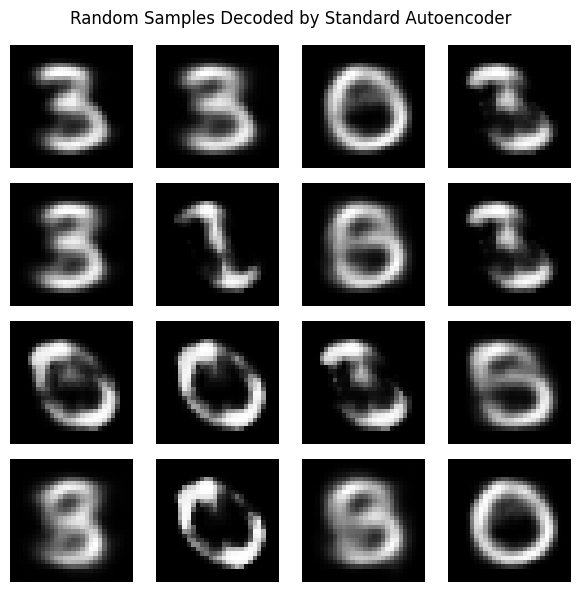


Final Comparison Summary
------------------------------------------------------------
Autoencoder Final Test Reconstruction Loss: 155.9503
VAE Final Test Total Loss:                 161.2626
VAE Final Test Reconstruction Loss:        156.2330
VAE Final Test KL Divergence:              5.0296
------------------------------------------------------------


{'Autoencoder Final Test Reconstruction Loss': 155.95028500976562,
 'VAE Final Test Total Loss': 161.2625635498047,
 'VAE Final Test Reconstruction Loss': 156.23300627441407,
 'VAE Final Test KL Divergence': 5.0295570358276365}

In [3]:
# ============================================================
# Understanding Variational Autoencoders:
# Learning and Generating Data with Latent Representations
# ============================================================
#
# This notebook compares:
# 1. A standard autoencoder
# 2. A variational autoencoder (VAE)
#
# using the MNIST handwritten digit dataset.
#
# The main teaching goals are to show:
# - how both models reconstruct images
# - why the VAE learns a smoother latent space
# - why VAEs can generate new samples from random latent vectors
# ============================================================


# =========================
# 1. Imports and setup
# =========================
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.manifold import TSNE

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 2. Load the MNIST dataset
# =========================
# MNIST images are 28x28 grayscale digits.
# We convert them to tensors with pixel values in [0, 1].
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Optional: use a subset for faster experimentation.
# Set these to None to use the full datasets.
TRAIN_SUBSET_SIZE = 20000
TEST_SUBSET_SIZE = 5000

if TRAIN_SUBSET_SIZE is not None:
    train_indices = list(range(TRAIN_SUBSET_SIZE))
    train_dataset = Subset(train_dataset, train_indices)

if TEST_SUBSET_SIZE is not None:
    test_indices = list(range(TEST_SUBSET_SIZE))
    test_dataset = Subset(test_dataset, test_indices)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


# =========================
# 3. Inspect sample images
# =========================
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


# =========================
# 4. Shared configuration
# =========================
INPUT_DIM = 28 * 28
HIDDEN_DIM = 256
LATENT_DIM = 2      # Keep this 2 so the latent space can be plotted directly
EPOCHS = 10
LEARNING_RATE = 1e-3


# =========================
# 5. Standard Autoencoder
# =========================
class Autoencoder(nn.Module):
    """
    Standard autoencoder.

    The encoder compresses the input into a latent vector z.
    The decoder reconstructs the original input from z.

    Unlike a VAE, this model does not enforce any structure on the latent space.
    That means it may reconstruct well, but random sampling from the latent space
    is usually not meaningful.
    """
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Output pixels in [0, 1]
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        reconstruction = self.decode(z)
        return reconstruction, z


# =========================
# 6. Variational Autoencoder
# =========================
class VariationalAutoencoder(nn.Module):
    """
    Variational Autoencoder (VAE).

    Instead of mapping an input to a single latent vector, the encoder produces:
    - a mean vector mu
    - a log-variance vector logvar

    A latent vector z is then sampled using the reparameterization trick:
        z = mu + std * eps

    This allows gradients to flow through the sampling process during training.
    """
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        # Shared encoder backbone
        self.encoder_backbone = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        # Separate heads for mean and log-variance
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_backbone(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Sample z using the reparameterization trick:
            z = mu + std * eps
        where eps ~ N(0, 1).
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar, z


# =========================
# 7. Loss functions
# =========================
def autoencoder_loss(reconstruction, x):
    """
    Reconstruction loss for the standard autoencoder.
    Binary cross-entropy is suitable because MNIST pixels are in [0, 1].
    """
    return F.binary_cross_entropy(reconstruction, x, reduction="sum")


def vae_loss(reconstruction, x, mu, logvar):
    """
    VAE loss = reconstruction loss + KL divergence

    Reconstruction loss encourages accurate image reconstruction.
    KL divergence regularizes the latent distribution toward N(0, 1).
    """
    reconstruction_term = F.binary_cross_entropy(reconstruction, x, reduction="sum")

    # KL divergence between q(z|x) and standard normal prior p(z) = N(0,1)
    kl_term = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total = reconstruction_term + kl_term
    return total, reconstruction_term, kl_term


# =========================
# 8. Training functions
# =========================
def train_autoencoder(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, _ in dataloader:
        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()

        reconstruction, _ = model(images)
        loss = autoencoder_loss(reconstruction, images)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(dataloader.dataset)
    return avg_loss


def evaluate_autoencoder(model, dataloader, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.view(images.size(0), -1).to(device)

            reconstruction, _ = model(images)
            loss = autoencoder_loss(reconstruction, images)

            running_loss += loss.item()

    avg_loss = running_loss / len(dataloader.dataset)
    return avg_loss


def train_vae(model, dataloader, optimizer, device):
    model.train()
    running_total = 0.0
    running_recon = 0.0
    running_kl = 0.0

    for images, _ in dataloader:
        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()

        reconstruction, mu, logvar, _ = model(images)
        loss, recon_term, kl_term = vae_loss(reconstruction, images, mu, logvar)

        loss.backward()
        optimizer.step()

        running_total += loss.item()
        running_recon += recon_term.item()
        running_kl += kl_term.item()

    n = len(dataloader.dataset)
    return running_total / n, running_recon / n, running_kl / n


def evaluate_vae(model, dataloader, device):
    model.eval()
    running_total = 0.0
    running_recon = 0.0
    running_kl = 0.0

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.view(images.size(0), -1).to(device)

            reconstruction, mu, logvar, _ = model(images)
            loss, recon_term, kl_term = vae_loss(reconstruction, images, mu, logvar)

            running_total += loss.item()
            running_recon += recon_term.item()
            running_kl += kl_term.item()

    n = len(dataloader.dataset)
    return running_total / n, running_recon / n, running_kl / n


# =========================
# 9. Initialize models
# =========================
autoencoder = Autoencoder().to(device)
vae = VariationalAutoencoder().to(device)

ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=LEARNING_RATE)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)


# =========================
# 10. Train the standard autoencoder
# =========================
ae_history = {
    "train_loss": [],
    "test_loss": []
}

print("Training standard autoencoder...\n")
for epoch in range(EPOCHS):
    train_loss = train_autoencoder(autoencoder, train_loader, ae_optimizer, device)
    test_loss = evaluate_autoencoder(autoencoder, test_loader, device)

    ae_history["train_loss"].append(train_loss)
    ae_history["test_loss"].append(test_loss)

    print(f"[AE] Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


# =========================
# 11. Train the VAE
# =========================
vae_history = {
    "train_total": [],
    "train_recon": [],
    "train_kl": [],
    "test_total": [],
    "test_recon": [],
    "test_kl": []
}

print("\nTraining variational autoencoder...\n")
for epoch in range(EPOCHS):
    train_total, train_recon, train_kl = train_vae(vae, train_loader, vae_optimizer, device)
    test_total, test_recon, test_kl = evaluate_vae(vae, test_loader, device)

    vae_history["train_total"].append(train_total)
    vae_history["train_recon"].append(train_recon)
    vae_history["train_kl"].append(train_kl)
    vae_history["test_total"].append(test_total)
    vae_history["test_recon"].append(test_recon)
    vae_history["test_kl"].append(test_kl)

    print(
        f"[VAE] Epoch {epoch+1}/{EPOCHS} | "
        f"Train Total: {train_total:.4f} | Train Recon: {train_recon:.4f} | Train KL: {train_kl:.4f} | "
        f"Test Total: {test_total:.4f} | Test Recon: {test_recon:.4f} | Test KL: {test_kl:.4f}"
    )


# =========================
# 12. Plot training curves
# =========================
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, ae_history["test_loss"], label="Autoencoder Test Loss")
plt.plot(epochs, vae_history["test_total"], label="VAE Test Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Test Loss Comparison: Autoencoder vs VAE")
plt.legend()
plt.tight_layout()
plt.savefig("loss_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, vae_history["test_recon"], label="VAE Reconstruction Loss")
plt.plot(epochs, vae_history["test_kl"], label="VAE KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss Components on Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("vae_loss_components.png", dpi=300)
plt.show()


# =========================
# 13. Reconstruction helper
# =========================
def show_reconstructions(model, dataloader, model_type="ae", n_images=8):
    """
    Display original images and reconstructions side by side.
    """
    model.eval()
    images, _ = next(iter(dataloader))
    images = images[:n_images].to(device)
    flat_images = images.view(images.size(0), -1)

    with torch.no_grad():
        if model_type == "ae":
            reconstructions, _ = model(flat_images)
        elif model_type == "vae":
            reconstructions, _, _, _ = model(flat_images)
        else:
            raise ValueError("model_type must be 'ae' or 'vae'")

    reconstructions = reconstructions.view(-1, 1, 28, 28).cpu()
    images = images.cpu()

    fig, axes = plt.subplots(2, n_images, figsize=(1.8 * n_images, 4))
    for i in range(n_images):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(reconstructions[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.show()


# =========================
# 14. Show reconstructions
# =========================
print("Standard Autoencoder Reconstructions")
show_reconstructions(autoencoder, test_loader, model_type="ae", n_images=8)

print("Variational Autoencoder Reconstructions")
show_reconstructions(vae, test_loader, model_type="vae", n_images=8)


# =========================
# 15. Extract latent representations
# =========================
def collect_latent_codes(model, dataloader, model_type="ae", max_points=3000):
    """
    Collect latent representations and labels for plotting.

    For the standard autoencoder, use z directly.
    For the VAE, use mu (the mean of the latent distribution), since it is
    more stable and interpretable than a sampled z.
    """
    model.eval()

    all_z = []
    all_labels = []

    collected = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.view(images.size(0), -1).to(device)

            if model_type == "ae":
                _, z = model(images)
            elif model_type == "vae":
                mu, logvar = model.encode(images)
                z = mu
            else:
                raise ValueError("model_type must be 'ae' or 'vae'")

            all_z.append(z.cpu())
            all_labels.append(labels)

            collected += images.size(0)
            if collected >= max_points:
                break

    z = torch.cat(all_z, dim=0)[:max_points].numpy()
    labels = torch.cat(all_labels, dim=0)[:max_points].numpy()

    return z, labels


# =========================
# 16. Plot latent spaces
# =========================
def plot_latent_space(z, labels, title, filename=None):
    """
    Plot a 2D latent space directly.
    This works because LATENT_DIM = 2.
    """
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7)
    plt.colorbar(scatter, label="Digit label")
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.title(title)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    plt.show()


ae_z, ae_labels = collect_latent_codes(autoencoder, test_loader, model_type="ae", max_points=3000)
vae_z, vae_labels = collect_latent_codes(vae, test_loader, model_type="vae", max_points=3000)

plot_latent_space(ae_z, ae_labels, "Standard Autoencoder Latent Space", filename="ae_latent_space.png")
plot_latent_space(vae_z, vae_labels, "VAE Latent Space (Using Mean Vector μ)", filename="vae_latent_space.png")


# =========================
# 17. Generate new samples from the VAE
# =========================
def generate_from_vae(model, n_samples=16):
    """
    Generate new samples by drawing latent vectors from N(0,1)
    and decoding them.
    """
    model.eval()

    with torch.no_grad():
        z = torch.randn(n_samples, LATENT_DIM).to(device)
        generated = model.decode(z).view(-1, 1, 28, 28).cpu()

    grid_size = int(np.sqrt(n_samples))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))

    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].squeeze(), cmap="gray")
        ax.axis("off")

    plt.suptitle("Images Generated from Random VAE Latent Samples")
    plt.tight_layout()
    plt.show()


generate_from_vae(vae, n_samples=16)


# =========================
# 18. Visualize a latent manifold
# =========================
def plot_vae_manifold(model, grid_size=15, scale=2.5):
    """
    Plot a grid of decoded images across a 2D latent space.
    This provides a visual demonstration of whether the latent space is smooth.
    """
    model.eval()

    # Create a grid in latent space
    grid_x = np.linspace(-scale, scale, grid_size)
    grid_y = np.linspace(-scale, scale, grid_size)

    canvas = np.zeros((28 * grid_size, 28 * grid_size))

    with torch.no_grad():
        for i, y in enumerate(grid_y):
            for j, x in enumerate(grid_x):
                z = torch.tensor([[x, y]], dtype=torch.float32).to(device)
                decoded = model.decode(z).view(28, 28).cpu().numpy()
                canvas[
                    (grid_size - 1 - i) * 28:(grid_size - i) * 28,
                    j * 28:(j + 1) * 28
                ] = decoded

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap="gray")
    plt.title("VAE Latent Manifold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("vae_latent_manifold.png", dpi=300)
    plt.show()


plot_vae_manifold(vae, grid_size=15, scale=2.5)


# =========================
# 19. Compare random decoding from the autoencoder
# =========================
def try_random_autoencoder_decoding(model, n_samples=16):
    """
    Decode random latent vectors using the standard autoencoder.

    This is included as a teaching comparison:
    because the autoencoder latent space is not regularized, random samples
    often do not produce meaningful digit images.
    """
    model.eval()

    with torch.no_grad():
        z = torch.randn(n_samples, LATENT_DIM).to(device)
        decoded = model.decode(z).view(-1, 1, 28, 28).cpu()

    grid_size = int(np.sqrt(n_samples))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))

    for i, ax in enumerate(axes.flat):
        ax.imshow(decoded[i].squeeze(), cmap="gray")
        ax.axis("off")

    plt.suptitle("Random Samples Decoded by Standard Autoencoder")
    plt.tight_layout()
    plt.show()


try_random_autoencoder_decoding(autoencoder, n_samples=16)


# =========================
# 20. Summary table
# =========================
print("\nFinal Comparison Summary")
print("-" * 60)
print(f"Autoencoder Final Test Reconstruction Loss: {ae_history['test_loss'][-1]:.4f}")
print(f"VAE Final Test Total Loss:                 {vae_history['test_total'][-1]:.4f}")
print(f"VAE Final Test Reconstruction Loss:        {vae_history['test_recon'][-1]:.4f}")
print(f"VAE Final Test KL Divergence:              {vae_history['test_kl'][-1]:.4f}")
print("-" * 60)


# =========================
# 21. Optional: compact results dictionary
# =========================
results = {
    "Autoencoder Final Test Reconstruction Loss": ae_history["test_loss"][-1],
    "VAE Final Test Total Loss": vae_history["test_total"][-1],
    "VAE Final Test Reconstruction Loss": vae_history["test_recon"][-1],
    "VAE Final Test KL Divergence": vae_history["test_kl"][-1],
}

results